### Stochastic interpolant demo: unit Gaussian → Gaussian mixture 

We learn a flow map from a simple **base** distribution to a more complex
**target** in 40-dimensions:

- **Base** `p_0`: a single unit Gaussian, `N(0, I)` (unit variance, zero covariance).
- **Target** `p_1`: a 16-center Gaussian mixture model with randomized mean and covariances.

The `EESI` model trains a drift field `b(t, x)` and score field `s(t, x)` along
the stochastic interpolant

$$x_t = \alpha(t)\,x_0 + \beta(t)\,x_1 + \gamma(t)\,z,\qquad z\sim N(0, I),$$

then estimates the entropy difference using a variety of strategies:
- integrate the learned probability-flow ODE (or reverse-time SDE) from
`t=0` (base) to `t=1` (target), acculumating entropy as either `b * s` or `div(b)` along the paths. 
- directly sample the interpolant from the data, taking the average of `b * s` or `div(b)`


In [1]:
# --- imports & environment ---
import sys
import pathlib

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 9
%matplotlib inline

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

from eesi import EESI, TimeMLP, GaussianMixture, gmm_ot_couple
from eesi.systems.gmm.train import train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. Base and target distributions

The base is standard normal, `N(0, I)`. The target is a 16-component Gaussian
mixture built from `eesi.systems.gmm.data.GaussianMixture`, whose weights, means and
full (correlated) covariances are drawn once from a fixed `seed` and then held
constant.

In [2]:
d = 40
# --- base: single 2D Gaussian, unit variance, zero covariance ---
base = MultivariateNormal(torch.zeros(d, device=device), torch.eye(d, device=device))

# --- target: 16-center Gaussian mixture from eesi.systems.gmm.data.GaussianMixture ---
# Same target used in the FEAT paper
target = GaussianMixture(dim=d,n_mixes=16,loc_scaling=2,
                            log_var_scaling=-3,seed=10,device=device)



### 2. Model & sampler setup

`EESI` wraps two `TimeMLP` fields: the drift `net_b` and the score `net_s`.

- `path="linear"` uses the simple linear interpolant `x_t = (1 - t) * x_0 + t * x_1`.
- `gamma="sqrt"` adds the latent-noise schedule `gamma(t) = gamma_scale * sqrt(t(1-t))`, and the
  score is trained with the cheap antithetic denoising objective (no divergence
  estimate).


In [3]:
torch.manual_seed(1)

net_b = TimeMLP(d=d, hidden=512, n_layers=4, activation="silu")
net_s = TimeMLP(d=d, hidden=3072, n_layers=2, activation="silu")

model = EESI(
    net_b, net_s,
    d=d,
    path="linear",
    gamma="sqrt",
    gamma_scale=0.2
).to(device)

#print(model)
print(sum(p.numel() for p in model.net_b.parameters()))
print(sum(p.numel() for p in model.net_s.parameters()))

model.net_b.load_state_dict(torch.load('./gmm2_b.pth'))
model.net_s.load_state_dict(torch.load('./gmm2_s.pth'))

1616936
38006824


<All keys matched successfully>

### 3. Training loop

`eesi.systems.gmm.train.train` runs the loop: each iteration draws a fresh batch from
the target `x_1` and from the base `x_0`, couples them by **minibatch optimal transport**
(`eesi.systems.gmm.ot`, squared-Euclidean cost), forms the interpolant internally, and returns the drift/score losses.

In [ ]:
# Starting with higher learning rate
model, htot = train(target, steps=10_000, batch=500, lr=1e-5, batch_ot=True,
                    device=device, model=model, log_every=100, entropy='both')


# grab training logs (loss_b, loss_s, and the free on-the-fly entropy estimators
# S_dot/S_zdot -- see eesi.systems.gmm.train's `--entropy` docs) and save the models
hist_b, hist_s, hist_S_dot, hist_S_zdot = np.asarray(htot).T
torch.save(model.net_b.state_dict(), './gmm5_b2.pth')
torch.save(model.net_s.state_dict(), './gmm5_s2.pth')

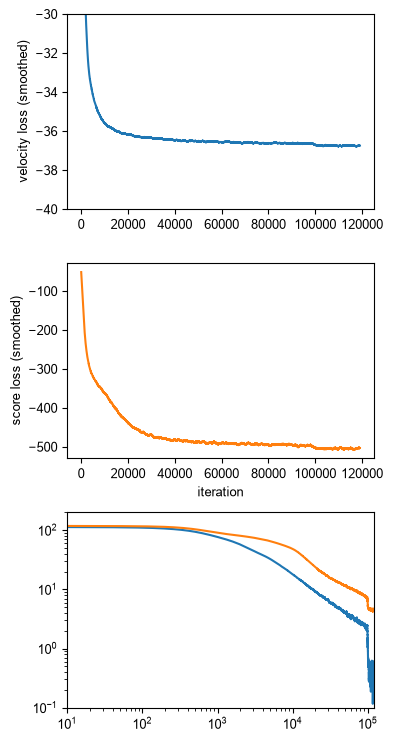

In [23]:
# Training curves (smoothed).
def smooth(v, k=1000):
    v = np.asarray(v)
    if len(v) < k:
        return v
    return np.convolve(v, np.ones(k) / k, mode="valid")

hist_b, hist_s, hist_S_dot, hist_S_zdot = np.load("./gmm_hist.npy").T
hist_b2, hist_s2, hist_S_dot2, hist_S_zdot2 = np.load("./gmm2_hist.npy").T
hist_b = np.concat((hist_b,hist_b2))
hist_s = np.concat((hist_s,hist_s2))
hist_S_dot = np.concat((hist_S_dot,hist_S_dot2))
hist_S_zdot = np.concat((hist_S_zdot,hist_S_zdot2))

fig, ax = plt.subplots(3,1,sharex=False,figsize=(4,7.5))
ax[0].plot(smooth(hist_b),'-C0')
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s),'-C1')
ax[1].set_xlabel("iteration") 
ax[1].set_ylabel("score loss (smoothed)")

s_target = -61.443-56.7575
ax[2].plot(smooth(hist_S_zdot)-s_target,'-')
ax[2].plot(smooth(hist_S_dot)-s_target,'-')
ax[2].set_yscale('log')
ax[2].set_xscale('log')
ax[2].set_ylim(0.1,200)
ax[0].set_ylim(-40,-30)
ax[2].set_xlim(1e1,1.2e5)
#ax[0].set_ylim(-37,-36)
plt.tight_layout()
plt.show()

### 4. Sampling

Map base samples to the target by integrating ODE/SDE's. `model.sample` with `eps=0.0` integrates the probability-flow **ODE** `dx/dt = b(t, x)` with Heun's method (drift only). Setting `eps > 0.0` integrates the **SDE** with Euler–Maruyama, using both the drift `b` and the learned score `s`.

Since we know the target distribution, we can (roughly) assess the quality of the samples and the anticipated entropy change by calculating the log probability.

In [7]:
# Draw base samples and push them through the model's built-in samplers.
torch.manual_seed(67)
x0 = base.sample((20000,))
x1 = target.sample((20000,))
gen_ode = model.sample(x0, n_steps=50)            # probability-flow ODE (drift only)
gen_sde = model.sample(x0, n_steps=100, eps=0.1)     # reverse-time SDE (drift + score)

# How well do generated samples match the target? (mean log-density)
ref = target.log_prob(x1).mean()
base_ref = base.log_prob(x0).mean()
print(f"mean target log-prob - true target : {ref:+.3f}")
print(f"mean target log-prob - ODE sampler : {target.log_prob(gen_ode).mean():+.3f}")
print(f"mean target log-prob - SDE sampler : {target.log_prob(gen_sde).mean():+.3f}")
print(f"mean base   log-prob - true base   : {base_ref:+.3f}")
print(f"estimated entropy change : {-ref + base_ref:+.3f}")

# predicted change in entropy based on log likelihood from direct sampling of the target
delta_pred = -ref + base_ref
delta_pred = delta_pred.cpu().numpy()


mean target log-prob - true target : +61.440
mean target log-prob - ODE sampler : +55.637
mean target log-prob - SDE sampler : +53.900
mean base   log-prob - true base   : -56.743
estimated entropy change : -118.184


In [21]:
import gc
gc.collect()
torch.cuda.empty_cache()

def strap(data,n_straps):
    data_size = len(data)
    means = np.zeros(n_straps)
    rng = np.random.default_rng()
    for i in range(n_straps):
        means[i] = np.mean(rng.choice(data, 
                                    size=data_size, 
                                    replace=True, 
                                    p=None, 
                                    axis=0, 
                                    shuffle=True))
    return means.mean(), 1.96*means.std()

# repeat a few times to avoid OOMs while still getting lots of data
x1 = target.sample((250000,))
data = target.log_prob(x1).cpu()

for _ in range(7):
    x1 = target.sample((250000,))
    data2 = target.log_prob(x1).cpu()
    data = torch.concat((data,data2))

mean,err = strap(data,10000)
print(-56.743-mean)
print(err)

-118.19084536399842
0.0061423651085570265


In [26]:
import gc
gc.collect()
torch.cuda.empty_cache()

### 5. Entropy along the paths

Including the flag `return_traj = True` in `model.sample` returns the whole integration trajectory. We also track entropy accumulation either by calculating the divergence of the velocity field `entropy="div"` (expensive!) or by taking the inner (dot) product of the velocity and score fields via `entropy="dot"`.

Sampling many trajectories, we get the full distribution of the running entropy accumulation associated with the probability flow.

In [30]:
# Trace the running entropy change along many ODE paths.
torch.manual_seed(100)
batch = 20000
x0 = base.sample((batch,))

# first sample using the dot product formula
traj, ent_traj, ts = model.sample(x0, n_steps=100, entropy='dot', return_traj=True)
ts_c = ts.cpu().numpy()
ent_c_dot = ent_traj.cpu().numpy()
dot_mean = ent_c_dot.mean(axis=1)
dot_std = ent_c_dot.std(axis=1)

# now with the divergence formula
traj, ent_traj, ts = model.sample(x0, n_steps=100, entropy='div', return_traj=True)
ent_c_div = ent_traj.cpu().numpy()
div_mean = ent_c_div.mean(axis=1)
div_std = ent_c_div.std(axis=1)


In [31]:
mean_dot,err_dot = strap(ent_c_dot[-1],10000)
mean_div,err_div = strap(ent_c_div[-1],10000)

print(f"observed entropy change        : {delta_pred:+.3f}")
print(f"estimated entropy change (dot) : {mean_dot:+.3f} +/- {err_dot:.3f}")
print(f"estimated entropy change (div) : {mean_div:+.3f} +/- {err_div:.3f}")


observed entropy change        : -118.184
estimated entropy change (dot) : -114.716 +/- 0.387
estimated entropy change (div) : -117.698 +/- 0.031


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


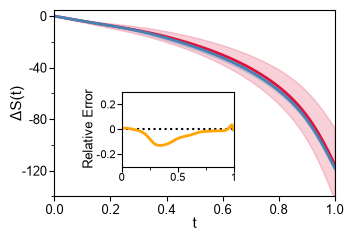

In [32]:
fig, ax = plt.subplots(figsize=(3.375, 2.25))
ax.plot(ts_c, dot_mean, c="crimson", lw=2, label="Dot Product")
ax.fill_between(ts_c, dot_mean - dot_std, dot_mean + dot_std, color='crimson', alpha=0.2)
ax.plot(ts_c, div_mean, c="steelblue", lw=2, label="Divergence")
ax.fill_between(ts_c, div_mean - div_std, div_mean + div_std, color='steelblue', alpha=0.2)

ax.set_xlabel("t",labelpad=0,fontsize=11); ax.set_ylabel(r"$\Delta$S(t)",labelpad=-3,fontsize=11)
ax.set_yticks([0,-40,-80,-120],labels=["0","-40","-80","-120"])
ax.set_yticks([-20,-60,-100,-140],labels=None,minor=True)
ax.tick_params(pad=2)
ax.set_ylim(-140,5)
ax.set_xlim(0,1)
#ax.grid(True,which='both',axis='both',color='gray', 
#        linestyle='--', linewidth=0.5, alpha=0.7)

dsdt_dot = np.diff(dot_mean)
dsdt_div = np.diff(div_mean)
err = dsdt_dot/dsdt_div - 1
t_diff = ts_c[:-1] + 0.5*(ts_c[1]-ts_c[0])

ins_ax = ax.inset_axes([.24, .16, 0.4, 0.4])
ins_ax.axhline(0,-1,1,color='k',linestyle=':',lw=1.5)
ins_ax.plot(t_diff, err, c="orange", lw=2, label="Difference")
ins_ax.set_xlim(0,1)
ins_ax.set_ylim(-0.3,0.3)
ins_ax.set_ylabel("Relative Error",fontsize=9,labelpad=1)
ins_ax.set_yticks([-0.2,0,0.2],labels=["-0.2","0","0.2"],fontsize=8)
ins_ax.set_xticks([0,0.5,1],labels=["0","0.5","1"],fontsize=8)
ins_ax.set_xticks([0.25,0.75],labels=None,minor=True)
ins_ax.tick_params(pad=1)

plt.subplots_adjust(0.14,0.15,0.97,0.98)

plt.savefig("gmm.eps",dpi=600)
plt.savefig("gmm.pdf",dpi=600)
plt.savefig("gmm.png",dpi=600)
plt.show()


### 6. Generation-Free Entropy Estimate

In [33]:
torch.manual_seed(35)
# IMPORTANT: this must be the same as the batch size used for 
# training if minibatch OT was used. The use of OT effectively alters
# the joint distribution of (x_0,x_1), which affects the interpolant 
# time marginals. To sample them properly, you must do the same coupling!
batch = 1000


means = []
for n in range(2000):
    x0 = base.sample((batch,))
    x1 = target.sample((batch,))
    #x0, x1 = gmm_ot_couple(x0, x1)
    ent = model.entropy_estimate(x1, x0, method='zdot')   # b*s formulation
    means.append(ent.mean().cpu().numpy())

mean_zdot,err_zdot = strap(means,10000)

print(f"observed entropy change        : {delta_pred:+.3f}")
print(f"estimated entropy change (zdot) : {mean_zdot:+.3f} +/- {err_zdot:.3f}")

print((np.mean(means)-delta_pred)/delta_pred)


observed entropy change        : -118.184
estimated entropy change (zdot) : -117.805 +/- 0.154
-0.003203437


In [ ]:
torch.manual_seed(36)
batch = 1000


means = []
for n in range(2000):
    x0 = base.sample((batch,))
    x1 = target.sample((batch,))
    #x0, x1 = gmm_ot_couple(x0, x1)
    ent = model.entropy_estimate(x1, x0, method='div')   # b*s formulation
    means.append(ent.mean().cpu().numpy())

mean_div,err_div = strap(means,10000)

print(f"observed entropy change        : {delta_pred:+.3f}")
print(f"estimated entropy change (div) : {mean_div:+.3f} +/- {err_div:.3f}")
print((np.mean(means)-delta_pred)/delta_pred)


observed entropy change        : -118.184
estimated entropy change (div) : -117.854 +/- 0.147
-0.00279054


In [35]:
torch.manual_seed(37)
batch = 1000


means = []
for n in range(2000):
    x0 = base.sample((batch,))
    x1 = target.sample((batch,))
    ent = model.entropy_estimate(x1, x0, "dot")   
    means.append(ent.mean().detach().cpu().numpy())

mean_dot,err_dot = strap(means,10000)

print(f"observed entropy change        : {delta_pred:+.3f}")
print(f"estimated entropy change (div) : {mean_dot:+.3f} +/- {err_dot:.3f}")
print((np.mean(means)-delta_pred)/delta_pred)


observed entropy change        : -118.184
estimated entropy change (div) : -112.188 +/- 0.147
-0.050736286
